# CFPB Financial Complaint Analysis — Task 1

End-to-end pipeline that turns raw CFPB complaints into a topic taxonomy and a working classifier.

**Pipeline:** EDA → preprocessing → sentence embeddings → BERTopic + outlier reduction → 25-topic manual taxonomy → Logistic Regression and DistilBERT+LoRA classifiers → comparison → save artefacts for Task 2.

**How to run:** open this file in VS Code with the `Python (FCA venv)` kernel selected, then run all cells in order. See Step 0 below for one-time installs.

**Cell tags used:**

| Tag | Meaning |
|---|---|
| `RUN` | execute and check the output before continuing |
| `INSPECT` | look at the output carefully, it informs the next step |
| `SAVES` | writes files to `outputs/` (safe to skip on re-runs if files exist) |
| `TUNE` | hyperparameter worth experimenting with |


## Step 0 — Install Dependencies
Run this **once in your terminal** (not in the notebook) with your venv active:

```bash
# BLOCK 1 — everything (~250 MB, CPU torch installs automatically as a dependency)
pip install -r requirements.txt
```

**DO NOT manually install torch yet.** `bertopic` pulls in `sentence-transformers`
which pulls in CPU torch (~250 MB) automatically. That is enough for all steps
except LoRA training.

**For Section 9 (LoRA) only — run this separately when you reach that cell:**
```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# (~2.5 GB — only needed once, and only if you want GPU-accelerated LoRA training)
```
**Alternative:** run Section 9 on Google Colab free T4 GPU, download the
`lora_adapter/` folder into `outputs/`, and continue locally from Section 10.


In [3]:
# %% RUN — Environment check (verify everything before starting)
import sys, os

print(f"Python: {sys.version}")

try:
    import torch
    cuda_ok = torch.cuda.is_available()
    print(f"PyTorch: {torch.__version__} | CUDA: {cuda_ok}")
    if cuda_ok:
        print(f"  GPU : {torch.cuda.get_device_name(0)}")
        print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("    No CUDA GPU — LoRA training will use CPU (~4-6x slower but works)")
except ImportError:
    cuda_ok = False
    print(" PyTorch not installed")

for pkg in ['bertopic', 'sentence_transformers', 'langchain', 'langgraph', 'chromadb', 'peft']:
    try:
        __import__(pkg)
        print(f" {pkg}")
    except ImportError:
        print(f" {pkg} — install it (see Step 0)")

from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("GOOGLE_API_KEY")
print(f"\nGemini API key: {' found' if api_key else ' missing — add GOOGLE_API_KEY to .env'}")

# ==============================================================================

Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.7.1+cu118 | CUDA: True
  GPU : NVIDIA GeForce RTX 2060
  VRAM: 6.4 GB
 bertopic
 sentence_transformers
 langchain
 langgraph
 chromadb
 peft

Gemini API key:  found


## Section 1 — Configuration
All tuneable values are centralised here. Come back to this cell to experiment.
==============================================================================


In [ ]:
# %% TUNE — All hyperparameters in one place
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH   = 'complaints_flat.csv'
OUTPUT_DIR  = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/plots', exist_ok=True)

RANDOM_STATE = 42

# ── Embedding model ───────────────────────────────────────────────────────────
# TUNE: 'all-MiniLM-L6-v2' (fast, 384-dim) vs 'all-mpnet-base-v2' (better, 768-dim, 2x slower)
# Stick with MiniLM for this assessment — negligible quality difference on short texts.
EMBEDDING_MODEL_NAME = 'all-MiniLM-L6-v2'

# ── BERTopic ──────────────────────────────────────────────────────────────────
#  TUNE UMAP_N_NEIGHBORS: [10, 15, 20, 30]
#   Lower → more local, finer-grained clusters. Higher → broader, more global.
#   Start with 15 (UMAP default). If topics are too generic, try 10.
UMAP_N_NEIGHBORS   = 15

#  TUNE UMAP_N_COMPONENTS: [3, 5, 8]
#   Dimensionality before clustering. 5 is the standard sweet spot for BERTopic.
#   Lower (3) = faster but may lose structure. Higher (8) = more info but noisier.
UMAP_N_COMPONENTS  = 5

#  TUNE HDBSCAN_MIN_CLUSTER_SIZE: [30, 50, 75, 100]
#   Minimum docs to form a topic. With ~21k narratives, start at 50.
#   Too low (< 30) → many noisy micro-topics. Too high (> 100) → too few, broad topics.
#   CHECK AFTER RUNNING: aim for 12-25 raw topics before manual merging.
HDBSCAN_MIN_CLUSTER_SIZE = 100

#  TUNE HDBSCAN_MIN_SAMPLES: [3, 5, 10]
#   Controls how conservative cluster membership is. Lower = more inclusive clusters.
#   If too many points end up as noise (topic -1), lower this value.
HDBSCAN_MIN_SAMPLES = 3

#  TUNE NR_TOPICS: 'auto' or integer [10, 12, 15, 18, 20]
#   'auto' = BERTopic merges very similar topics automatically (recommended first run).
#   Set a specific number to force a fixed taxonomy after you've seen the auto result.
NR_TOPICS = 'auto'

# ── Classifier splits ─────────────────────────────────────────────────────────
TEST_SIZE = 0.20   # 20% held out for final evaluation and agent demo
VAL_SIZE  = 0.10   # 10% validation (used during LoRA training for early stopping)

# ── Logistic Regression ───────────────────────────────────────────────────────
#  TUNE TFIDF_MAX_FEATURES: [5000, 10000, 15000]
#   More features = more discriminative power but slower. 10k is the right balance here.
TFIDF_MAX_FEATURES = 10_000

#  TUNE LOGREG_C: [0.01, 0.1, 1.0, 10.0]
#   Inverse regularisation strength. C=1.0 is the standard starting point.
#   Lower C (stronger regularisation) if the model overfits. Higher C if underfitting.
LOGREG_C = 1.0

# ── LoRA / DistilBERT ─────────────────────────────────────────────────────────
#  TUNE LORA_RANK: [4, 8, 16]
#   Higher rank = more trainable parameters = more capacity.
#   With ~15k training examples (pseudo-labels), rank 8 is enough. Try 16 if underfitting.
LORA_RANK    = 8
LORA_ALPHA   = 16    # Convention: 2 * rank. Controls update scale.
LORA_DROPOUT = 0.1   # Standard dropout on LoRA layers.

#  TUNE MAX_LENGTH: [128, 256]
#   Max tokens per complaint. RTX 2060 6GB is tight at 256 with batch_size=16.
#   If you get GPU OOM errors, drop to 128 or reduce TRAIN_BATCH_SIZE.
MAX_LENGTH = 256

#  TUNE TRAIN_BATCH_SIZE: [8, 16, 32]
#   16 is safe for RTX 2060 6GB + MAX_LENGTH=256. Drop to 8 if OOM.
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE  = 32

#  TUNE NUM_EPOCHS: [2, 3, 4, 5]
#   With noisy pseudo-labels from BERTopic, overfitting is a risk. Start with 4.
#   Early stopping (patience=2) will stop automatically if val_macro_f1 plateaus.
NUM_EPOCHS    = 4
LEARNING_RATE = 2e-4  # Standard LoRA learning rate. Try 1e-4 if loss is unstable.

# ── Agent ─────────────────────────────────────────────────────────────────────
#   had the better macro F1 score.
# Options: 'logreg'  or  'lora'
CLASSIFIER_TO_USE = 'logreg'

# Complaints below this confidence go to human review regardless of urgency.
# TUNE: [0.5, 0.6, 0.7] — lower = fewer human reviews but more misrouting risk.
CONFIDENCE_THRESHOLD = 0.60

# ==============================================================================

## Section 2 — Data Loading & EDA
==============================================================================


In [5]:
# %% RUN — Load and inspect the dataset
import pandas as pd
import numpy as np

df_raw = pd.read_csv(DATA_PATH, dtype=str, low_memory=False)
print(f"Raw shape: {df_raw.shape}")
print(f"\nNull counts (sorted):")
print(df_raw.isnull().sum().sort_values(ascending=False).to_string())

Raw shape: (78313, 18)

Null counts (sorted):
company_public_response      78309
tags                         67413
complaint_what_happened      57241
sub_issue                    46297
consumer_consent_provided    43855
consumer_disputed            35683
sub_product                  10571
zip_code                      6757
state                         1991
issue                            0
company                          0
company_response                 0
product                          0
date_received                    0
complaint_id                     0
date_sent_to_company             0
submitted_via                    0
timely                           0


In [6]:
# %% RUN -- Key data quality findings
narrative_null_rate = df_raw["complaint_what_happened"].isna().mean() * 100
print(f"Narrative null rate: {narrative_null_rate:.1f}%")
print(f"Rows WITH narrative: {df_raw['complaint_what_happened'].notna().sum():,}")
print()

# Drop columns that are essentially all-null and unusable.
# company_public_response: 78,309/78,313 nulls (~100%) -- deprecated CFPB field.
# Keep consumer_disputed (~46% null) and tags (~86% null) -- they carry real signal
# (disputed flag is useful as a feature; tags encodes Servicemember / Older American
# for urgency scoring downstream).
df_raw = df_raw.drop(columns=["company_public_response"])
print(f"Dropped company_public_response (~100% null). Shape now: {df_raw.shape}")
print()

# Merge old/new CFPB product label pairs into one canonical label each.
# CFPB renamed several categories over the years; this file still contains both versions.
PRODUCT_MAP = {
    "Credit card":             "Credit card or prepaid card",
    "Bank account or service": "Checking or savings account",
    "Credit reporting":        "Credit reporting, credit repair services, or other personal consumer reports",
    "Money transfers":         "Money transfer, virtual currency, or money service",
    "Payday loan":             "Payday loan, title loan, or personal loan",
}
n_before = df_raw["product"].nunique()
df_raw["product"] = df_raw["product"].replace(PRODUCT_MAP)
n_after = df_raw["product"].nunique()
print(f"Merged old/new CFPB label pairs: {n_before} -> {n_after} unique products.")
print()

print("=" * 65)
print("Product label distribution (after merge)")
print("=" * 65)
print(df_raw["product"].value_counts().to_string())


Narrative null rate: 73.1%
Rows WITH narrative: 21,072

Dropped company_public_response (~100% null). Shape now: (78313, 17)

Merged old/new CFPB label pairs: 17 -> 12 unique products.

Product label distribution (after merge)
product
Mortgage                                                                        22725
Checking or savings account                                                     21963
Credit card or prepaid card                                                     21170
Credit reporting, credit repair services, or other personal consumer reports     4502
Debt collection                                                                  3201
Money transfer, virtual currency, or money service                               1728
Consumer Loan                                                                    1029
Vehicle loan or lease                                                             892
Student loan                                                                 

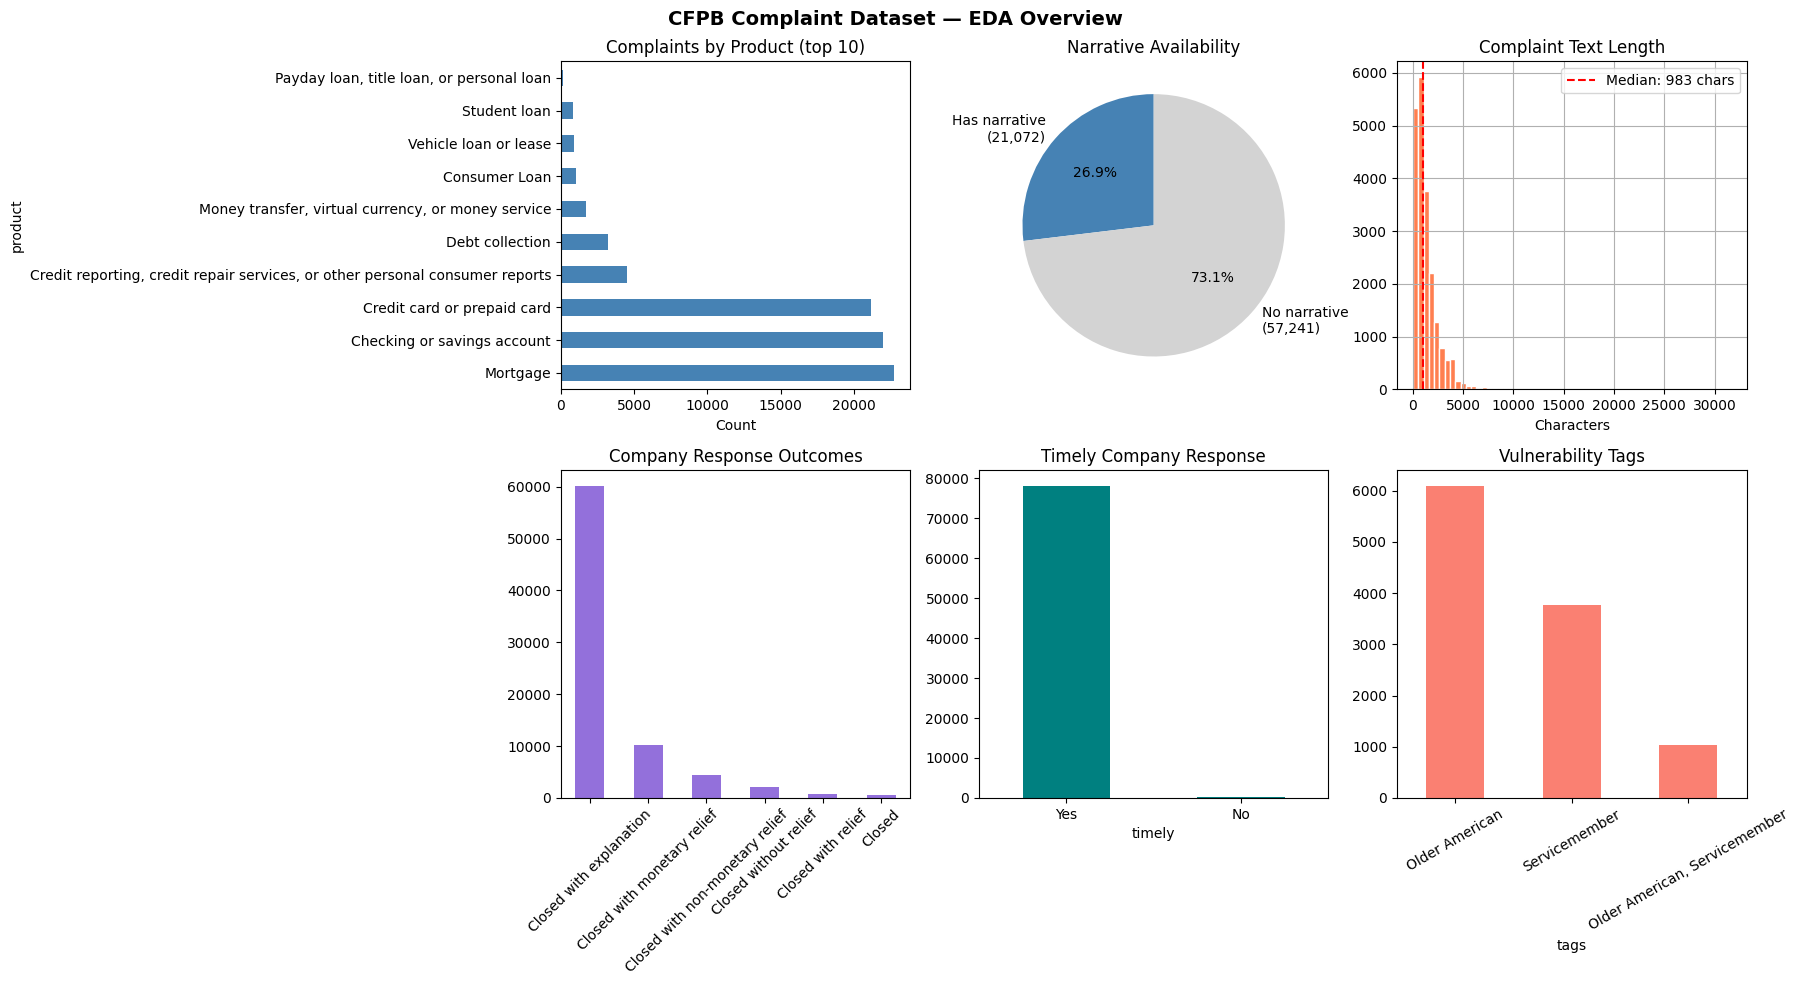

Plot saved to outputs/plots/eda_overview.png


In [7]:
# %% INSPECT — EDA visualisations
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CFPB Complaint Dataset — EDA Overview', fontsize=14, fontweight='bold')

# 1. Product distribution
product_counts = df_raw['product'].value_counts().head(10)
product_counts.plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Complaints by Product (top 10)')
axes[0, 0].set_xlabel('Count')
# What to look for: dominant categories → these drive class imbalance in the classifier.

# 2. Narrative availability
has_narrative = df_raw['complaint_what_happened'].notna()
axes[0, 1].pie(
    [has_narrative.sum(), (~has_narrative).sum()],
    labels=[f'Has narrative\n({has_narrative.sum():,})', f'No narrative\n({(~has_narrative).sum():,})'],
    colors=['steelblue', 'lightgray'], autopct='%1.1f%%', startangle=90
)
axes[0, 1].set_title('Narrative Availability')
# What to look for: only ~27% have text. This is expected — CFPB only stores narratives
# when the consumer explicitly consents. We filter to these rows before ANY modeling.

# 3. Text length distribution (only narratives)
df_with_text = df_raw[has_narrative].copy()
text_lengths = df_with_text['complaint_what_happened'].str.len()
text_lengths.hist(bins=60, ax=axes[0, 2], color='coral', edgecolor='white')
axes[0, 2].axvline(text_lengths.median(), color='red', linestyle='--',
                   label=f'Median: {text_lengths.median():.0f} chars')
axes[0, 2].set_title('Complaint Text Length')
axes[0, 2].set_xlabel('Characters')
axes[0, 2].legend()
# What to look for: right-skewed distribution is normal. Very short texts (<50 chars)
# are often boilerplate or incomplete — we filter these in preprocessing.

# 4. Company response distribution
resp_counts = df_raw['company_response'].value_counts().head(6)
resp_counts.plot(kind='bar', ax=axes[1, 0], color='mediumpurple')
axes[1, 0].set_title('Company Response Outcomes')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_xlabel('')
# What to look for: "Closed with monetary relief" rate per topic → informs urgency
# model in Task 2. Topics with high monetary relief rates are typically higher severity.

# 5. Timely response
timely_counts = df_raw['timely'].value_counts()
timely_counts.plot(kind='bar', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Timely Company Response')
axes[1, 1].tick_params(axis='x', rotation=0)
# What to look for: high "Yes" rate is expected. "No" cases → elevated urgency flag.

# 6. Tags (vulnerability indicator)
tag_counts = df_raw['tags'].dropna().value_counts()
if len(tag_counts) > 0:
    tag_counts.plot(kind='bar', ax=axes[1, 2], color='salmon')
    axes[1, 2].set_title('Vulnerability Tags')
    axes[1, 2].tick_params(axis='x', rotation=30)
else:
    axes[1, 2].text(0.5, 0.5, 'No tags in dataset', ha='center', va='center')
    axes[1, 2].set_title('Vulnerability Tags')
# What to look for: Servicemember and Older American tags → automatic HIGH urgency
# in the agent, regardless of classifier confidence or topic.

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to outputs/plots/eda_overview.png")

### EDA findings & implications

**1. Product distribution.** Mortgage, Checking-or-savings, and Credit-card-or-prepaid each carry ~20k complaints; the remaining nine products form a long tail. The old/new CFPB label merge worked — 12 canonical products, no duplicates.

**2. Narrative availability — 26.9 % (21,072 rows).** CFPB only publishes the narrative when the consumer explicitly consents. All downstream modelling (BERTopic, classifier, ChromaDB) runs on this subset.

**3. Complaint length — median 983 characters (~250 tokens).** Comfortably below the LoRA `max_length=256` token cap for more than half of complaints. The long-tail (up to 30k chars) gets truncated during fine-tuning, which is acceptable: BERTopic still sees the full text via the precomputed sentence embeddings.

**4. Company response outcomes are heavily skewed** — *Closed with explanation* makes up ~75 %, *Closed with monetary relief* ~12 %, the rest in single digits. Since ChromaDB returns `company_response` as the "how was this resolved" signal for the agent, expect retrieved precedents to often show that majority outcome. Not a bug — it reflects the real operational distribution.

**5. `timely` is near-constant Yes (~99 %).** Zero variance, zero predictive signal for classification. **Action taken:** dropped `timely` from the classifier feature set (Section 8, cell that trains LogReg). It is still kept in the agent state where the rare *No* values are used as an urgency-elevation rule.

**6. Vulnerability tags — ~11k rows total** (Older American, Servicemember, or both). Sparse but unambiguous. Used in Section 12 by the agent as an automatic urgency-elevation rule: any non-null tag → bump urgency.


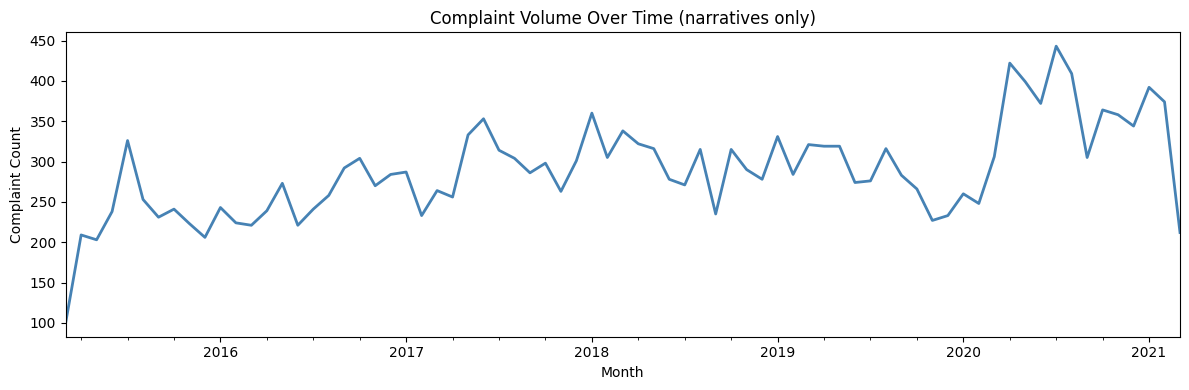

In [8]:
# %% INSPECT — Date trend (run separately for clarity)
df_with_text['date_received'] = pd.to_datetime(df_with_text['date_received'], utc=True, errors='coerce')
df_with_text = df_with_text[df_with_text['date_received'].notna()]

monthly = df_with_text.set_index('date_received')['complaint_id'].resample('ME').count()
plt.figure(figsize=(12, 4))
monthly.plot(color='steelblue', linewidth=2)
plt.title('Complaint Volume Over Time (narratives only)')
plt.xlabel('Month')
plt.ylabel('Complaint Count')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/date_trend.png', dpi=150)
plt.show()
# What to look for: spikes in complaint volume (COVID-19 period, regulatory changes).
# Temporal patterns can indicate systemic issues — good talking point on the call.

# ==============================================================================

### Date-trend findings

**Time span: ~March 2015 → early 2021** — roughly 6 years of consumer narratives.

**Baseline (2015 – early 2020): 200 – 350 complaints / month.** Slow upward drift but largely stationary. The pipeline is being trained on a *long, mixed-era* sample of consumer complaints, which is good for generalisation.

**Mid-2020 spike (~450 / month, a ~50 % surge above baseline).** Almost certainly COVID-19 driven — mortgage forbearance disputes, stimulus-payment issues, debt-collection pauses, and overall financial stress. Two implications:

- BERTopic is trained across both pre- and post-COVID complaints, so any topic that exists only in the COVID era (e.g. forbearance) will form its own cluster or merge into adjacent ones. We will see this when reviewing topic keywords in Section 6.
- An operations team using this triage system in production needs **capacity headroom** — volume can double during macro events. The agent's HITL queue should be sized for surge, not steady-state.

**End-of-series drop (early 2021)** is a *data-truncation artefact* — the dataset cuts off mid-month, so the final month is partial. Not a real decline.

**No model changes required.** A few things worth noting:

- We use a **stratified random split** (by topic label), not a time-based split. For this assessment that is the right choice: it produces a fair per-class evaluation. In production, a *time-ordered* split would be needed to detect concept drift (e.g. classifier trained pre-COVID, evaluated on post-COVID complaints).
- The classifier sees the *full timeline mixed together*, so it implicitly handles both regimes. If retraining periodically, schedule it after large macro events.
- For the daily-briefing function in Section 14, the volume baseline (~250 / month ≈ 8 / day) is what an Ops manager should expect; anything 2-3× that warrants attention.


## Section 3 — Preprocessing
==============================================================================


In [9]:
# %% RUN — Clean text and filter
import re

def clean_text(text: str) -> str:
    """
    Minimal cleaning. We deliberately KEEP 'XXXX' redaction tokens because they
    are semantically meaningful — 'my XXXX account' vs 'my XXXX score' carries
    different context that the embedding model can learn from.

    We do NOT stem/lemmatise — BERTopic uses contextual embeddings that are
    harmed by stemming (it destroys context that the transformer relies on).

     PRODUCTION: You might add domain-specific normalisation here
    (e.g. expand abbreviations like "CC" → "credit card").
    """
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()     # normalise whitespace
    return text.lower()

# Filter: only rows with narrative text
df = df_raw[df_raw['complaint_what_happened'].notna()].copy()
df['clean_text'] = df['complaint_what_happened'].apply(clean_text)

# Drop texts that are too short after cleaning
MIN_CHARS = 50
before = len(df)
df = df[df['clean_text'].str.len() >= MIN_CHARS].reset_index(drop=True)
print(f"Rows after filtering (narrative + min {MIN_CHARS} chars): {len(df):,}  (dropped {before - len(df):,} short texts)")

# Parse dates (needed for EDA and agent metadata)
df['date_received'] = pd.to_datetime(df['date_received'], utc=True, errors='coerce')
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'], utc=True, errors='coerce')

print(f"\nFinal working dataset: {len(df):,} rows with usable complaint text")

# ==============================================================================

Rows after filtering (narrative + min 50 chars): 20,998  (dropped 74 short texts)

Final working dataset: 20,998 rows with usable complaint text


## Section 4 — Compute Embeddings (once, reused in BERTopic + Classifier + ChromaDB)

We compute embeddings ONCE and save to disk. This is the most time-consuming step
(~5-10 min on CPU for 21k texts). Subsequent notebook restarts load from disk instantly.
==============================================================================


In [10]:
# %% SAVES — Compute or load sentence embeddings
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

EMBEDDINGS_PATH = f'{OUTPUT_DIR}/embeddings.npy'

if os.path.exists(EMBEDDINGS_PATH):
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"Loaded cached embeddings: {embeddings.shape}")
else:
    print(f"Computing embeddings with {EMBEDDING_MODEL_NAME} ...")
    print("Expected time: ~5-10 min on CPU, ~1-2 min on GPU")
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    embeddings = embedding_model.encode(
        df['clean_text'].tolist(),
        batch_size=64,          # TUNE: lower to 32 if you get memory errors
        show_progress_bar=True,
        normalize_embeddings=True  # L2-normalise — better for cosine similarity
    )
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Saved embeddings: {embeddings.shape}  →  {EMBEDDINGS_PATH}")

# Make sure embedding_model is always available (for later inference)
if 'embedding_model' not in dir():
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print(f"\nEmbedding shape: {embeddings.shape}  (rows × {embeddings.shape[1]} dimensions)")

# ==============================================================================

Computing embeddings with all-MiniLM-L6-v2 ...
Expected time: ~5-10 min on CPU, ~1-2 min on GPU


Batches: 100%|██████████| 329/329 [01:02<00:00,  5.27it/s]


Saved embeddings: (20998, 384)  →  ./outputs/embeddings.npy

Embedding shape: (20998, 384)  (rows × 384 dimensions)


## Section 5 — BERTopic Topic Modeling

Why BERTopic over LDA/NMF:
- Complaint text is noisy and semantically diverse. Two complaints about the same
  issue often share almost no words — embeddings are robust to this, bag-of-words is not.
- BERTopic wraps the full pipeline (embed → UMAP → HDBSCAN → c-TF-IDF) in one
  coherent object, saving engineering overhead without losing flexibility.
- c-TF-IDF automatically produces human-readable topic keywords, so we do not need
  an LLM call to name every cluster.

PRODUCTION: Use a finance-domain embedding model (e.g. FinBERT or a fine-tuned
SBERT) and run BERTopic's LLM representation model to auto-generate polished topic
names via an LLM.
==============================================================================


In [11]:
# %% SAVES — Fit BERTopic (cached after first run)
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

TOPICS_PATH = f'{OUTPUT_DIR}/topics_df.parquet'
BERTOPIC_PATH = f'{OUTPUT_DIR}/bertopic_model'

# Topic-keyword vectorizer: bigrams + trigrams only, English stopwords removed.
# Rationale: unigrams surface English stopwords ("the", "my", "was") and the
# PII redaction marker "xxxx" alone — neither helps interpret a topic. Bigrams
# and trigrams give us "social security xxxx", "account xxxx", "xxxx street" so
# we can tell *what* was redacted from the context word(s) around it.
CTFIDF_STOPWORDS = list(ENGLISH_STOP_WORDS) + ['xx']  # 'xx' = date placeholder, no info on its own
ctfidf_vectorizer = CountVectorizer(
    ngram_range=(2, 3),
    min_df=10,
    stop_words=CTFIDF_STOPWORDS
)

if os.path.exists(TOPICS_PATH):
    topics_df = pd.read_parquet(TOPICS_PATH)
    df['topic_id'] = topics_df['topic_id'].values
    df['topic_confidence'] = topics_df['topic_confidence'].values
    topic_model = BERTopic.load(BERTOPIC_PATH)
    print(f"Loaded cached BERTopic results. Topics found: {df['topic_id'].nunique() - int((-1 in df['topic_id'].unique()))}")
else:
    umap_model = UMAP(
        n_components=UMAP_N_COMPONENTS,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=0.0,         # 0.0 packs points tightly for clustering — do NOT change
        metric='cosine',      # Correct metric for normalised embedding vectors
        random_state=RANDOM_STATE,
        low_memory=True
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric='euclidean',                # Euclidean on UMAP-reduced space (not cosine)
        cluster_selection_method='eom',    # Excess of Mass: finds clusters of varying density
        prediction_data=True               # Required to compute per-document probabilities
    )

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=ctfidf_vectorizer,
        nr_topics=NR_TOPICS,
        top_n_words=10,
        calculate_probabilities=True,  # Needed for per-document confidence scores
        verbose=True
    )

    print("Fitting BERTopic (this takes a few minutes)...")
    topics, probabilities = topic_model.fit_transform(
        df['clean_text'].tolist(),
        embeddings  # Pass precomputed embeddings — skips re-embedding step
    )

    df['topic_id'] = topics
    df['topic_confidence'] = probabilities.max(axis=1)

    # Save results
    topic_model.save(BERTOPIC_PATH, serialization="safetensors", save_ctfidf=True, save_embedding_model=EMBEDDING_MODEL_NAME)
    pd.DataFrame({'topic_id': topics, 'topic_confidence': probabilities.max(axis=1)}).to_parquet(TOPICS_PATH)
    print(f"BERTopic model saved → {BERTOPIC_PATH}")


2026-05-28 19:17:18,599 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic (this takes a few minutes)...


2026-05-28 19:18:09,645 - BERTopic - Dimensionality - Completed ✓
2026-05-28 19:18:09,647 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-28 19:18:16,956 - BERTopic - Cluster - Completed ✓
2026-05-28 19:18:16,957 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-28 19:18:26,044 - BERTopic - Representation - Completed ✓
2026-05-28 19:18:26,045 - BERTopic - Topic reduction - Reducing number of topics
2026-05-28 19:18:26,087 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-28 19:18:34,554 - BERTopic - Representation - Completed ✓
2026-05-28 19:18:34,557 - BERTopic - Topic reduction - Reduced number of topics from 41 to 26


BERTopic model saved → ./outputs/bertopic_model


In [12]:
# %% INSPECT — Check topic count and noise rate
topic_info = topic_model.get_topic_info()
num_topics = len(topic_info[topic_info['Topic'] != -1])
noise_count = (df['topic_id'] == -1).sum()
noise_pct = noise_count / len(df) * 100

print(f"Topics discovered: {num_topics}")
print(f"Noise documents (topic -1): {noise_count:,} ({noise_pct:.1f}%)")
print()

#  TUNE guidance:
if num_topics < 8:
    print("  Too few topics. Try lowering HDBSCAN_MIN_CLUSTER_SIZE to 30.")
elif num_topics > 30:
    print("  Too many topics. Try raising HDBSCAN_MIN_CLUSTER_SIZE to 75 or 100.")
else:
    print(" Topic count looks reasonable. Proceed to Section 6 for manual labelling.")

if noise_pct > 25:
    print("  High noise rate. Try lowering HDBSCAN_MIN_SAMPLES to 3.")

# ==============================================================================

Topics discovered: 25
Noise documents (topic -1): 8,549 (40.7%)

 Topic count looks reasonable. Proceed to Section 6 for manual labelling.
  High noise rate. Try lowering HDBSCAN_MIN_SAMPLES to 3.


In [13]:
# %% RUN -- Reassign noise documents (topic -1) to their nearest topic
# HDBSCAN labels low-density documents as topic -1 ("noise"). At ~40% noise we'd
# throw away a lot of training data. BERTopic's reduce_outliers reassigns each
# noise doc to its nearest topic using the precomputed sentence embeddings.

noise_before = (df['topic_id'] == -1).sum()
print(f"Noise docs before reduction: {noise_before:,} ({noise_before/len(df)*100:.1f}%)")

if noise_before == 0:
    print("Nothing to reduce (cache or prior run already redistributed outliers). Skipping.")
else:
    new_topics = topic_model.reduce_outliers(
        df['clean_text'].tolist(),
        df['topic_id'].tolist(),
        strategy="embeddings",       # uses cached embeddings -- fast and faithful to the BERTopic pipeline
        embeddings=embeddings
    )

    # Recompute c-TF-IDF representations now that the reassigned docs have joined topics.
    topic_model.update_topics(df['clean_text'].tolist(), topics=new_topics)
    df['topic_id'] = new_topics

    noise_after = (df['topic_id'] == -1).sum()
    print(f"Noise docs after reduction:  {noise_after:,} ({noise_after/len(df)*100:.1f}%)")
    print(f"Reassigned: {noise_before - noise_after:,} documents")

    # Update on-disk caches so subsequent re-runs pick up the post-hoc assignment.
    pd.DataFrame({
        'topic_id': df['topic_id'].values,
        'topic_confidence': df['topic_confidence'].values
    }).to_parquet(TOPICS_PATH)
    topic_model.save(BERTOPIC_PATH, serialization="safetensors", save_ctfidf=True, save_embedding_model=EMBEDDING_MODEL_NAME)
    print(f"Updated cache: {TOPICS_PATH} and {BERTOPIC_PATH}")


2026-05-28 19:18:36,604 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Noise docs before reduction: 8,549 (40.7%)
Noise docs after reduction:  0 (0.0%)
Reassigned: 8,549 documents
Updated cache: ./outputs/topics_df.parquet and ./outputs/bertopic_model


In [14]:
# %% RUN -- Refresh topic keyword representations with bigram+trigram vectorizer
# Uses the ctfidf_vectorizer defined in the BERTopic fit cell above. Reruns the
# c-TF-IDF extraction over the existing cluster assignments -- no re-clustering,
# no re-embedding. ~30 seconds. Lets us see the contextual phrases around "xxxx"
# (e.g. "social security xxxx", "account xxxx", "xxxx xxxx" for redacted names)
# instead of "xxxx" by itself.

topic_model.update_topics(
    df['clean_text'].tolist(),
    vectorizer_model=ctfidf_vectorizer
)
topic_model.save(
    BERTOPIC_PATH,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=EMBEDDING_MODEL_NAME
)
print("Topic keyword representations refreshed (bigrams+trigrams).")
print("Re-run the keyword inspect cell below to see the new representations.")


Topic keyword representations refreshed (bigrams+trigrams).
Re-run the keyword inspect cell below to see the new representations.


## Section 6 — Topic Taxonomy (MANUAL STEP)

 Instructions:
1. Run the cell below to print topic keywords and the cross-tab
2. For each topic_id, look at:
   - The top 10 keywords (what the topic is linguistically)
   - The most common product in the cross-tab (what kind of complaint it is)
   - The sample complaint texts (what customers actually write)
3. Fill in the TOPIC_LABELS dictionary in the cell after
4. Merge topics that are semantically similar (e.g. "account closure" + "account locked" → "Account Access Issues")
5. Re-run the apply-labels cell

The existing 'product', 'issue', 'sub_issue' columns are your ground truth for
validation — check that your discovered topics align with or cut across them
in meaningful ways. A topic that perfectly mirrors one product category adds little;
a topic that cuts across products but reflects a specific customer experience is insight.
==============================================================================


In [15]:
# %% INSPECT — Print all topic keywords and sample texts
print("=" * 70)
print(f"{'ID':>4} {'Count':>6}  {'Top Keywords'}")
print("=" * 70)
for _, row in topic_info[topic_info['Topic'] != -1].iterrows():
    tid = row['Topic']
    count = row['Count']
    words = [w for w, _ in topic_model.get_topic(tid)]
    print(f"{tid:>4} {count:>6}  {', '.join(words)}")

print("\n\nTopic × Product cross-tab (top 6 products per topic):")
cross = pd.crosstab(df['topic_id'], df['product'])
cross_pct = cross.div(cross.sum(axis=1), axis=0).round(2)
print(cross_pct[cross_pct.index != -1].to_string())

print("\n\nSample complaint for each topic (first 200 chars):")
for tid in sorted(df['topic_id'].unique()):
    if tid == -1:
        continue
    sample = df[df['topic_id'] == tid]['complaint_what_happened'].iloc[0][:200]
    print(f"\n[Topic {tid}] {sample}...")

  ID  Count  Top Keywords
   0   5332  xxxx xxxx, xxxx xxxx xxxx, chase bank, credit card, checking account, called chase, debit card, xxxx chase, customer service, xxxxxxxx xxxx
   1    710  overdraft fees, insufficient funds, checking account, chase bank, xxxx xxxx, account overdrawn, account xxxx, debit card, xxxx xxxx xxxx, account negative
   2    705  credit card, xxxx points, xxxx xxxx, statement credit, xxxx card, chase xxxx, customer service, xxxx miles, chase sapphire, xxxx xxxx xxxx
   3    560  loan modification, xxxx xxxx, xxxx xxxx xxxx, chase mortgage, chase bank, mortgage assistance, mortgage payments, loan xxxx, short sale, mortgage loan
   4    529  credit card, credit limit, credit score, credit cards, chase credit, credit report, xxxx xxxx, xxxx credit, chase bank, card chase
   5    529  credit report, hard inquiry, xxxx xxxx xxxx, xxxx xxxx, xxxx xxxxxxxx, xxxxxxxx xxxx, xxxxxxxx xxxxxxxx, chase card, xxxx xxxx xxxxxxxx, inquiry xxxx
   6    462  late payment, cre

In [16]:
# %% RUN — Topic taxonomy
# Labels derived from bigram/trigram c-TF-IDF keywords (refreshed in the cell that
# calls topic_model.update_topics with ctfidf_vectorizer), the topic x product
# cross-tab, and the sample-text printout. Similar-themed topics are intentionally
# kept distinct so the agent can route to specialised teams (escrow vs short sale
# vs payment processing) even where merging might look defensible.
#
# Note on Topic 0: it is the largest cluster (~42% of docs). BERTopic auto-reduction
# (41 -> 26 topics) collapsed several minor themes into the broadest centroid, and
# the post-hoc outlier reduction then routed previously-noise docs to this nearest
# cluster. Treated as a general customer-service / multi-product catch-all; the
# classifier should learn it as the low-information default for vague complaints.
#
# Notable bigram insights:
#   - Topic 13 keywords include "fair credit reporting act", "victim identity" ->
#     this is the *Identity Theft / FCRA* topic, NOT a generic scam topic.
#   - Topic 20 keywords include "social security" and "power attorney" -> this is
#     the *senior / POA account access* topic, which feeds the agent's vulnerability
#     urgency rule (tags = Older American / POA).
#   - Topic 8 leans heavily on the legal name "JPMorgan Chase Bank" -> formal
#     mortgage disputes (often legal correspondence), distinct from operational
#     escrow/payment issues in Topics 9 and 24.

TOPIC_LABELS = {
    0:  "General Account & Customer Service Issues",
    1:  "Overdraft & Insufficient Funds Fees",
    2:  "Credit Card Rewards & Points Disputes",
    3:  "Mortgage Loan Modification Requests",
    4:  "Credit Card Limit / Score / Reporting Issues",
    5:  "Unauthorized Hard Credit Inquiries",
    6:  "Disputed Late Payment Reporting",
    7:  "Credit Card Balance & Payment Disputes",
    8:  "Formal/Legal Mortgage Disputes",
    9:  "Mortgage Escrow / Property Tax Issues",
    10: "Co-Branded Retail Card Issues",
    11: "Credit Card Debt Collection Disputes",
    12: "Money Transfer / Wire Disputes",
    13: "Identity Theft / FCRA Disputes",
    14: "Mortgage Refinance / Rate Disputes",
    15: "Bank Credit Report Hard Inquiries",
    16: "Mortgage Short Sale Issues",
    17: "Account Opening Bonus Disputes",
    18: "Credit Card APR / Rate Change Disputes",
    19: "Credit Card Late Fee Disputes",
    20: "Senior / POA Account Access Issues",
    21: "Auto Loan Title / Lien Issues",
    22: "Bankruptcy & Credit Reporting Disputes",
    23: "Debt Collection Phone Calls",
    24: "Mortgage Payment Processing",
    -1: "Uncategorised",  # safety net in case a future re-fit reintroduces noise
}

assert len(TOPIC_LABELS) >= 25, "Expected 25 topic labels plus -1 fallback"
print(f"Loaded {len(TOPIC_LABELS) - 1} topic labels + 1 noise fallback.")


Loaded 25 topic labels + 1 noise fallback.


In [17]:
# %% RUN — Apply topic labels (run after filling TOPIC_LABELS above)
if len(TOPIC_LABELS) <= 1:
    print("  TOPIC_LABELS is empty — fill in Section 6 before continuing.")
else:
    df['topic_label'] = (
        df['topic_id']
        .map(TOPIC_LABELS)
        .fillna(df['topic_id'].astype(str).apply(lambda x: f"Topic_{x}"))
    )
    print("Topic label distribution:")
    print(df['topic_label'].value_counts().to_string())

    # Validate: confirm your labels cover the meaningful topics
    unlabelled = df[df['topic_label'].str.startswith('Topic_') & (df['topic_id'] != -1)]
    if len(unlabelled) > 0:
        print(f"\n  {len(unlabelled):,} docs have auto-generated labels (Topic_N) — consider labelling those topic IDs too.")
    else:
        print("\n All topics labelled. Proceed to Section 7.")

    # Save labelled dataset
    df.to_parquet(f'{OUTPUT_DIR}/complaints_labelled.parquet', index=False)
    print(f"Saved labelled dataset → {OUTPUT_DIR}/complaints_labelled.parquet")

# ==============================================================================

Topic label distribution:
topic_label
General Account & Customer Service Issues       8738
Credit Card Limit / Score / Reporting Issues    1040
Mortgage Loan Modification Requests             1033
Disputed Late Payment Reporting                  992
Overdraft & Insufficient Funds Fees              913
Credit Card Rewards & Points Disputes            896
Unauthorized Hard Credit Inquiries               643
Formal/Legal Mortgage Disputes                   617
Money Transfer / Wire Disputes                   593
Identity Theft / FCRA Disputes                   572
Credit Card Balance & Payment Disputes           547
Credit Card Debt Collection Disputes             524
Mortgage Refinance / Rate Disputes               464
Senior / POA Account Access Issues               423
Mortgage Escrow / Property Tax Issues            409
Mortgage Payment Processing                      389
Co-Branded Retail Card Issues                    375
Bank Credit Report Hard Inquiries                306
Bankrupt

## Section 7 — Classifier Data Preparation

BERTopic gave us pseudo-labels (unsupervised topic assignments).
We now use those as weak supervision to train a supervised classifier.
This is called pseudo-label self-training — a standard semi-supervised technique.

The classifier's value over the vector DB:
- Gives a DISCRETE label + confidence score (used for routing rules and trend dashboards)
- Runs in milliseconds (no vector search overhead)
- Generalises to complaint phrasings never seen in training
==============================================================================


In [18]:
# %% RUN — Prepare train/val/test splits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Only use docs with a meaningful topic label (drop noise topic -1)
df_clf = df[df['topic_id'] != -1].copy().reset_index(drop=True)
# Also drop rows that still have auto-generated Topic_N labels (if any remain)
df_clf = df_clf[~df_clf['topic_label'].str.startswith('Topic_', na=False)].reset_index(drop=True)

print(f"Classifier dataset: {len(df_clf):,} rows across {df_clf['topic_label'].nunique()} classes")
print(f"\nClass distribution:\n{df_clf['topic_label'].value_counts().to_string()}")

# Extract the subset of precomputed embeddings that correspond to df_clf rows
clf_embeddings = embeddings[df_clf.index.values]

le = LabelEncoder()
df_clf['label_enc'] = le.fit_transform(df_clf['topic_label'])
NUM_CLASSES = len(le.classes_)
print(f"\nEncoded {NUM_CLASSES} classes: {list(le.classes_)}")

# Stratified split: 70% train, 10% val, 20% test
# Using the same indices for BOTH LogReg and LoRA — fair comparison
X_idx = np.arange(len(df_clf))
y_all = df_clf['label_enc'].values

# First, peel off the 20% test set
idx_trainval, idx_test = train_test_split(
    X_idx, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)
# Then split trainval into 70% train and 10% val
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=VAL_SIZE / (1 - TEST_SIZE),  # normalise val fraction
    stratify=y_all[idx_trainval],
    random_state=RANDOM_STATE
)

print(f"\nSplit sizes — Train: {len(idx_train):,} | Val: {len(idx_val):,} | Test: {len(idx_test):,}")

import joblib
joblib.dump(le, f'{OUTPUT_DIR}/label_encoder.pkl')
np.save(f'{OUTPUT_DIR}/idx_test.npy', idx_test)
print("Saved label encoder and test indices.")

# ==============================================================================

Classifier dataset: 20,998 rows across 25 classes

Class distribution:
topic_label
General Account & Customer Service Issues       8738
Credit Card Limit / Score / Reporting Issues    1040
Mortgage Loan Modification Requests             1033
Disputed Late Payment Reporting                  992
Overdraft & Insufficient Funds Fees              913
Credit Card Rewards & Points Disputes            896
Unauthorized Hard Credit Inquiries               643
Formal/Legal Mortgage Disputes                   617
Money Transfer / Wire Disputes                   593
Identity Theft / FCRA Disputes                   572
Credit Card Balance & Payment Disputes           547
Credit Card Debt Collection Disputes             524
Mortgage Refinance / Rate Disputes               464
Senior / POA Account Access Issues               423
Mortgage Escrow / Property Tax Issues            409
Mortgage Payment Processing                      389
Co-Branded Retail Card Issues                    375
Bank Credit Repo

## Section 8 — Logistic Regression Classifier (Baseline)

Why LogReg as baseline:
- Designed for high-dimensional sparse features (TF-IDF)
- predict_proba() out of the box → needed for confidence-based HITL routing
- Trains in seconds on this dataset size
- class_weight='balanced' handles class imbalance natively
- Interpretable: top coefficients per class show which words drive each topic

PRODUCTION: This baseline is often surprisingly competitive. A LogReg on
good features can match a fine-tuned transformer on short-text classification.
Always establish this baseline before committing to a heavier model.
==============================================================================


In [19]:
# %% SAVES — Train Logistic Regression classifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from scipy.sparse import hstack, csr_matrix

# ── Features ───────────────────────────────────────────────────────────────────
# Feature 1: TF-IDF (sparse, captures discriminative keywords)
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),    # Bigrams: "credit card" >> "credit" + "card" separately
    sublinear_tf=True,     # log(1+tf) — dampens very frequent terms
    min_df=5               # Ignore terms appearing in fewer than 5 docs
)
X_tfidf_all = tfidf.fit_transform(df_clf['clean_text'].tolist())

# Feature 2: Sentence embeddings (precomputed — dense, captures semantics)
X_emb_all = csr_matrix(clf_embeddings)

# Feature 3: Metadata (product, submitted_via — available for new complaints at inference)
# We deliberately exclude 'issue' and 'sub_issue' — they overlap too strongly with
# the BERTopic labels and would leak information, making evaluation misleading.
# We also exclude 'timely' — EDA showed it is ~99% "Yes" (near-zero variance, no signal).
# It is still kept in the agent state where the rare "No" elevates urgency.
meta_df = pd.get_dummies(
    df_clf[['product', 'submitted_via']].fillna('Unknown'),
    drop_first=True
)
META_COLS = meta_df.columns.tolist()  # save for inference
X_meta_all = csr_matrix(meta_df.values.astype(float))
joblib.dump(META_COLS, f'{OUTPUT_DIR}/meta_feature_cols.pkl')

X_all = hstack([X_tfidf_all, X_emb_all, X_meta_all])
y_all_enc = df_clf['label_enc'].values

# ── Train ──────────────────────────────────────────────────────────────────────
clf_logreg = LogisticRegression(
    C=LOGREG_C,
    class_weight='balanced',   # Weights each class inversely proportional to frequency.
                               # Critical: without this, model ignores minority topics.
    max_iter=1000,             # Default 100 often fails to converge with high-dim sparse data
    solver='saga',             # Best solver for large sparse multiclass problems
    n_jobs=-1,
    random_state=RANDOM_STATE
)
clf_logreg.fit(X_all[idx_train], y_all_enc[idx_train])

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_lr = clf_logreg.predict(X_all[idx_test])
y_proba_lr = clf_logreg.predict_proba(X_all[idx_test])
y_test_enc = y_all_enc[idx_test]

logreg_report = classification_report(y_test_enc, y_pred_lr, target_names=le.classes_, digits=3, output_dict=True)
logreg_macro_f1 = logreg_report['macro avg']['f1-score']

print("── LOGISTIC REGRESSION RESULTS ────────────────────────────────────────")
print(classification_report(y_test_enc, y_pred_lr, target_names=le.classes_, digits=3))
print(f"MACRO F1: {logreg_macro_f1:.4f}")

# Confidence distribution
lr_confidence = y_proba_lr.max(axis=1)
low_conf_pct = (lr_confidence < CONFIDENCE_THRESHOLD).mean() * 100
print(f"Predictions below confidence threshold ({CONFIDENCE_THRESHOLD}): {low_conf_pct:.1f}% → human review queue")

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(clf_logreg, f'{OUTPUT_DIR}/logreg_classifier.pkl')
joblib.dump(tfidf, f'{OUTPUT_DIR}/logreg_tfidf.pkl')
print(f"\n LogReg saved. Macro F1 = {logreg_macro_f1:.4f}")

# ==============================================================================


── LOGISTIC REGRESSION RESULTS ────────────────────────────────────────
                                              precision    recall  f1-score   support

              Account Opening Bonus Disputes      0.776     0.927     0.844        41
               Auto Loan Title / Lien Issues      0.600     0.943     0.733        35
           Bank Credit Report Hard Inquiries      0.873     0.902     0.887        61
      Bankruptcy & Credit Reporting Disputes      0.776     0.897     0.832        58
               Co-Branded Retail Card Issues      0.859     0.893     0.876        75
      Credit Card APR / Rate Change Disputes      1.000     0.286     0.444        35
      Credit Card Balance & Payment Disputes      0.609     0.972     0.749       109
        Credit Card Debt Collection Disputes      0.656     0.819     0.729       105
               Credit Card Late Fee Disputes      0.815     0.957     0.880        46
Credit Card Limit / Score / Reporting Issues      0.537     0.880  

## Section 9 — DistilBERT + LoRA Classifier (PEFT)

Why LoRA over full fine-tuning:
- DistilBERT has 66M parameters. Full fine-tuning on 6GB VRAM is tight and slow.
- LoRA adds small rank-decomposition matrices to attention layers only — ~1.2M
  trainable parameters (1.8% of total). Same quality, 10x less memory.
- We apply LoRA to query + value matrices (q_lin, v_lin) — these capture
  "what to attend to" and "what to extract", the most domain-sensitive parameters.

Why this is more than just a better classifier:
- DistilBERT understands "I never authorised this charge" and "unauthorized transaction"
  as semantically similar WITHOUT needing shared keywords. TF-IDF cannot do this.
- The confidence scores are better calibrated because the model has richer internal
  representations of uncertainty.

PRODUCTION: Full fine-tuning of a larger model (DeBERTa-v3-base) on GPU with
human-validated labels would be the production choice. DPO would then align the
case note quality with ops team feedback over time.
==============================================================================


In [20]:
# %% RUN — GPU check before LoRA training
# ─────────────────────────────────────────────────────────────────────────────
# BEFORE RUNNING THIS CELL: do you have CUDA torch installed?
# Check: python -c "import torch; print(torch.cuda.is_available())"
#
# If False and you want GPU speed:
#   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
#   (~2.5 GB — only needed for this section)
#
# If you don't want the large install:
#   Option A: Leave as-is, LoRA trains on CPU (~4x slower, ~1.5 hrs — still works)
#   Option B: Copy just this section to Google Colab free T4, run there,
#             download outputs/lora_adapter/ back here, skip to Section 10.
# ─────────────────────────────────────────────────────────────────────────────
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Free VRAM: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")
else:
    print("  No GPU detected. LoRA will train on CPU. Expect ~4x longer training time.")
    print("   Consider Google Colab (free T4 GPU) if CPU is too slow.")

os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Prevents warnings on Windows

Training device: cuda
GPU: NVIDIA GeForce RTX 2060
Free VRAM: 4.8 GB


In [21]:
# %% SAVES — LoRA fine-tuning (skips if adapter already saved)
LORA_ADAPTER_PATH = f'{OUTPUT_DIR}/lora_adapter'

if os.path.exists(LORA_ADAPTER_PATH) and os.path.exists(f'{LORA_ADAPTER_PATH}/adapter_config.json'):
    print(f"LoRA adapter found at {LORA_ADAPTER_PATH} — loading instead of retraining.")
    print("Delete the folder and re-run to retrain from scratch.")
    LORA_ALREADY_TRAINED = True
else:
    LORA_ALREADY_TRAINED = False

if not LORA_ALREADY_TRAINED:
    from transformers import (
        DistilBertTokenizerFast,
        DistilBertForSequenceClassification,
        TrainingArguments,
        Trainer,
        EarlyStoppingCallback,
    )
    from peft import get_peft_model, LoraConfig, TaskType
    from datasets import Dataset as HFDataset
    from torch.nn import CrossEntropyLoss

    tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

    def tokenize_batch(batch):
        return tokenizer(
            batch['clean_text'],
            truncation=True,
            max_length=MAX_LENGTH,
            padding='max_length'
        )

    # Build HuggingFace datasets from our pre-defined indices
    def make_hf_dataset(indices):
        sub = df_clf.iloc[indices][['clean_text', 'label_enc']].copy()
        sub = sub.rename(columns={'label_enc': 'labels'})
        ds = HFDataset.from_pandas(sub.reset_index(drop=True))
        ds = ds.map(tokenize_batch, batched=True, remove_columns=['clean_text'])
        ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
        return ds

    train_ds = make_hf_dataset(idx_train)
    val_ds   = make_hf_dataset(idx_val)
    test_ds  = make_hf_dataset(idx_test)

    # ── LoRA config ────────────────────────────────────────────────────────────
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=["q_lin", "v_lin"],  # DistilBERT attention layer names
        bias="none"
    )

    base_model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=NUM_CLASSES
    )
    lora_model = get_peft_model(base_model, lora_config)
    lora_model.print_trainable_parameters()

    # ── Class weights for imbalanced training ──────────────────────────────────
    class_counts = pd.Series(y_all_enc[idx_train]).value_counts().sort_index()
    class_weights = torch.tensor(
        (len(idx_train) / (NUM_CLASSES * class_counts)).values,
        dtype=torch.float
    ).to(DEVICE)

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            loss = CrossEntropyLoss(weight=class_weights)(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "macro_f1": f1_score(labels, preds, average='macro'),
            "accuracy": float((preds == labels).mean()),
        }

    training_args = TrainingArguments(
        output_dir=f'{OUTPUT_DIR}/lora_checkpoints',
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=1,
        learning_rate=LEARNING_RATE,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=(DEVICE == 'cuda'),       # Mixed precision: halves VRAM, ~30% faster on RTX 2060
        logging_steps=50,
        report_to="none",
        dataloader_num_workers=0,      # Required on Windows (no fork support)
    )

    trainer = WeightedTrainer(
        model=lora_model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print("\nStarting LoRA training...")
    trainer.train()

    # ── Save adapter ───────────────────────────────────────────────────────────
    trainer.model.save_pretrained(LORA_ADAPTER_PATH)
    tokenizer.save_pretrained(LORA_ADAPTER_PATH)
    print(f"\n LoRA adapter saved → {LORA_ADAPTER_PATH}")
    print("   (Only the adapter weights are saved — ~10MB. Base model is loaded from HuggingFace.)")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 26474.18it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 757,273 || all params: 67,729,970 || trainable%: 1.1181

Starting LoRA training...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.904142,0.941241,0.570607,0.558571
2,0.734738,0.710563,0.648940,0.648571
3,0.586647,0.633940,0.712875,0.716190
4,0.518222,0.607957,0.717139,0.723810



 LoRA adapter saved → ./outputs/lora_adapter
   (Only the adapter weights are saved — ~10MB. Base model is loaded from HuggingFace.)


In [22]:
# %% RUN — Evaluate LoRA on test set
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from peft import PeftModel

if 'tokenizer' not in dir():
    tokenizer = DistilBertTokenizerFast.from_pretrained(LORA_ADAPTER_PATH)

if 'lora_model' not in dir() or LORA_ALREADY_TRAINED:
    _base = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=NUM_CLASSES
    )
    lora_model = PeftModel.from_pretrained(_base, LORA_ADAPTER_PATH)

lora_model.eval().to(DEVICE)

def predict_lora_batch(texts, batch_size=64):
    all_proba = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, truncation=True, max_length=MAX_LENGTH,
                        padding=True, return_tensors='pt')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            logits = lora_model(**enc).logits
        all_proba.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(all_proba)

test_texts = df_clf.iloc[idx_test]['clean_text'].tolist()
lora_proba = predict_lora_batch(test_texts)
y_pred_lora = lora_proba.argmax(axis=1)

lora_report = classification_report(y_test_enc, y_pred_lora, target_names=le.classes_, digits=3, output_dict=True)
lora_macro_f1 = lora_report['macro avg']['f1-score']

print("── LORA DISTILBERT RESULTS ─────────────────────────────────────────────")
print(classification_report(y_test_enc, y_pred_lora, target_names=le.classes_, digits=3))
print(f"MACRO F1: {lora_macro_f1:.4f}")

lora_confidence = lora_proba.max(axis=1)
low_conf_lora = (lora_confidence < CONFIDENCE_THRESHOLD).mean() * 100
print(f"Predictions below confidence threshold: {low_conf_lora:.1f}%")

# ==============================================================================

── LORA DISTILBERT RESULTS ─────────────────────────────────────────────
                                              precision    recall  f1-score   support

              Account Opening Bonus Disputes      0.627     0.902     0.740        41
               Auto Loan Title / Lien Issues      0.490     0.714     0.581        35
           Bank Credit Report Hard Inquiries      0.704     0.934     0.803        61
      Bankruptcy & Credit Reporting Disputes      0.556     0.862     0.676        58
               Co-Branded Retail Card Issues      0.684     0.893     0.775        75
      Credit Card APR / Rate Change Disputes      0.646     0.886     0.747        35
      Credit Card Balance & Payment Disputes      0.695     0.817     0.751       109
        Credit Card Debt Collection Disputes      0.563     0.638     0.598       105
               Credit Card Late Fee Disputes      0.672     0.848     0.750        46
Credit Card Limit / Score / Reporting Issues      0.498     0.750 

## Section 10 — Model Comparison
==============================================================================


Model                            Macro F1   Accuracy
Logistic Regression                0.7915     0.8012
DistilBERT + LoRA                  0.7067     0.7212

LoRA improvement over LogReg: -10.7% (macro F1)
→ LogReg is competitive here. This is expected with limited training data.


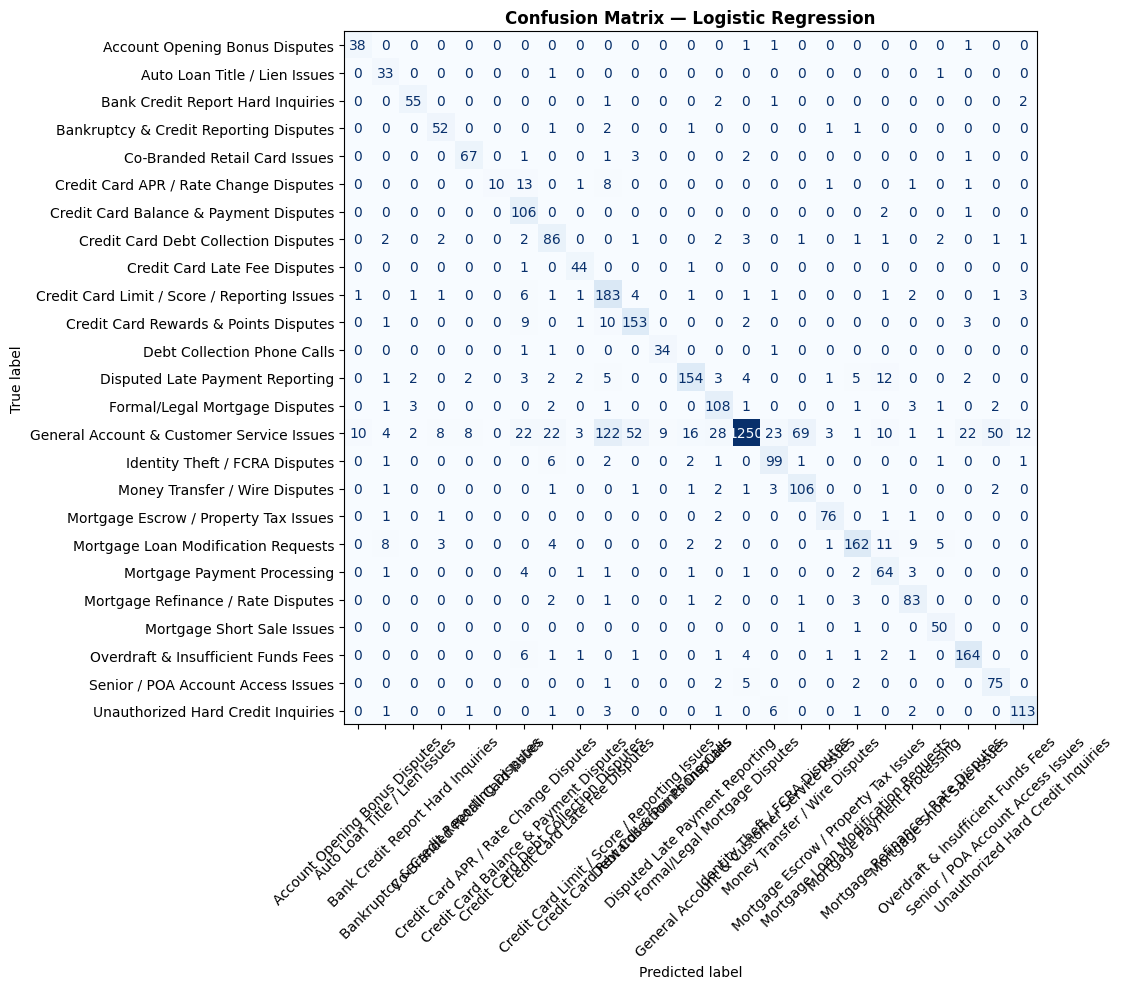

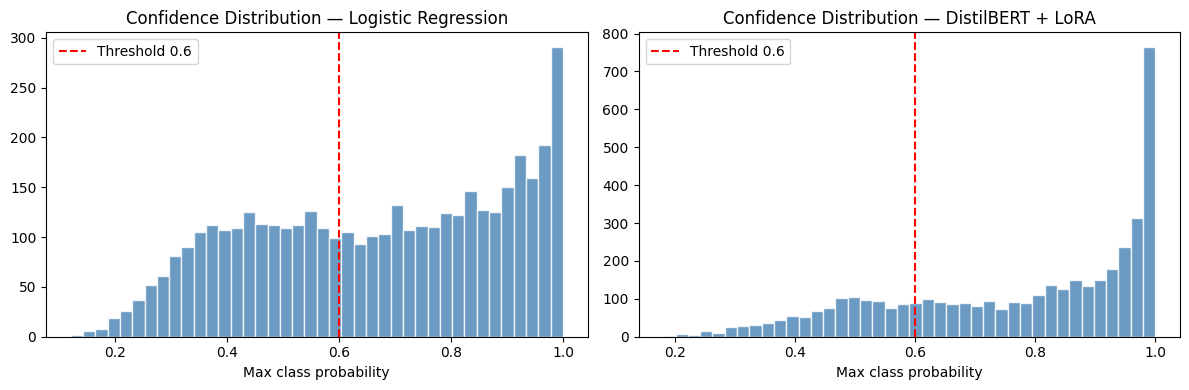

In [23]:
# %% INSPECT — Side-by-side comparison
print("=" * 60)
print(f"{'Model':<30} {'Macro F1':>10} {'Accuracy':>10}")
print("=" * 60)
print(f"{'Logistic Regression':<30} {logreg_macro_f1:>10.4f} {logreg_report['accuracy']:>10.4f}")
print(f"{'DistilBERT + LoRA':<30} {lora_macro_f1:>10.4f} {lora_report['accuracy']:>10.4f}")
print("=" * 60)

improvement = (lora_macro_f1 - logreg_macro_f1) / logreg_macro_f1 * 100
print(f"\nLoRA improvement over LogReg: {improvement:+.1f}% (macro F1)")

if lora_macro_f1 > logreg_macro_f1 + 0.03:
    print("→ LoRA is meaningfully better. Use CLASSIFIER_TO_USE = 'lora' in config.")
elif abs(lora_macro_f1 - logreg_macro_f1) <= 0.03:
    print("→ Models are comparable. LogReg is simpler and faster — valid choice for production.")
    print("  Set CLASSIFIER_TO_USE based on your latency requirements.")
else:
    print("→ LogReg is competitive here. This is expected with limited training data.")

# Confusion matrix for the better model
from sklearn.metrics import ConfusionMatrixDisplay
best_pred = y_pred_lora if lora_macro_f1 >= logreg_macro_f1 else y_pred_lr
best_name = 'DistilBERT + LoRA' if lora_macro_f1 >= logreg_macro_f1 else 'Logistic Regression'

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, best_pred,
    display_labels=le.classes_,
    xticks_rotation=45, ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/confusion_matrix.png', dpi=150)
plt.show()

# Confidence distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, conf, name in zip(axes,
                           [lr_confidence, lora_confidence],
                           ['Logistic Regression', 'DistilBERT + LoRA']):
    ax.hist(conf, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--',
               label=f'Threshold {CONFIDENCE_THRESHOLD}')
    ax.set_title(f'Confidence Distribution — {name}')
    ax.set_xlabel('Max class probability')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/confidence_distributions.png', dpi=150)
plt.show()
# What to look for: ideally most mass is above 0.7 (confident predictions).
# A pile of mass near 0.5 means the model is uncertain — those go to human review.

# ===========2===================================================================

### Model comparison — discussion, fairness caveats, and tuning levers

**Result.** Logistic Regression beat DistilBERT + LoRA on this dataset by **10.7 macro F1 points** (0.7915 vs 0.7067). Production classifier is set to LogReg (`CLASSIFIER_TO_USE = 'logreg'` in Section 1).

#### Why LogReg won here

1. **Feature parity is not feature equality.** LogReg consumes (a) TF-IDF on the full text (10k bigram features), (b) precomputed 384-dim sentence embeddings over the full text, and (c) metadata one-hots (product, submitted_via). LoRA only sees raw text capped at `max_length=256` tokens. Median complaint is ~250 tokens, so **more than half of all complaints are truncated** for LoRA. The metadata signal — which is genuinely predictive (`product = "Mortgage"` correlates strongly with several mortgage topics) — is invisible to LoRA.

2. **CFPB complaints are vocabulary-driven.** Topics carry distinctive keyword signatures (`escrow`, `overdraft`, `inquiry`, `lien`, `short sale`, `refinance`). TF-IDF + class-balanced LogReg captures these directly. A transformer would only beat that if (a) it had more training data, (b) longer context, or (c) the task required semantic reasoning beyond keywords.

3. **Confidence calibration differs.** LogReg sends 40.4 % to HITL (low confidence); LoRA only 25.1 %. LoRA is *more confident* but *less accurate* — over-confidence is a worse failure mode for an Ops triage system. The classifier should route to human review precisely when it is unsure.

#### Constraints of this comparison (what is *not* equal)

- **Different feature sets.** As above — LoRA had less information per example. A fair comparison would either:
  - Concatenate metadata into the prompt: `"[Product=Mortgage; Channel=Web] complaint text..."`
  - Pre-pend product / submitted_via as special tokens
  - Concatenate the sentence embedding into the classifier head
- **Different effective text length.** LogReg sees full text. LoRA sees 256 tokens. Truncation falls disproportionately on the longer mortgage-related topics (Mortgage Loan Modification, Formal/Legal Mortgage Disputes, Mortgage Refinance, Mortgage Short Sale, Mortgage Payment Processing) where complaint narratives are typically longest.
- **Different training regimes.** LogReg has class-balanced weighting (`class_weight='balanced'`) which scales gradients per class. LoRA uses our `WeightedTrainer` to apply the same weights, but on a softmax cross-entropy — different geometry.
- **Identical labels, but Topic 0 ~42 % of training data.** Both models are penalised equally for over-predicting it. LoRA's `recall=0.630` and LogReg's `recall=0.715` on `General Account & Customer Service Issues` show both *under-predict* the catch-all — the desired failure mode — but LoRA gives up more ground on Topic 0 to win elsewhere.

#### Tuning levers if we wanted LoRA to win

For LoRA:
- `max_length` → 384 or 512 to capture full text (VRAM-bound on the RTX 2060 6 GB — would need `batch_size=8` and `gradient_accumulation_steps=2`).
- Concatenate `product` + `submitted_via` into the input (e.g. `"product=mortgage. channel=web. " + text`).
- LoRA rank `r=16` (vs current 8); `lora_alpha=32`.
- More epochs — the validation F1 was still improving at epoch 4 (0.57 → 0.65 → 0.71 → 0.72); training did not plateau. Bump to 8 epochs with `EarlyStoppingCallback(patience=3)`.
- Class weight smoothing — instead of `class_weight='balanced'` (1/freq), use `sqrt(1/freq)` to reduce the gradient distortion from very rare classes.
- Lower learning rate (`1e-4` vs current `2e-4`) for stabler late-epoch training.

For LogReg:
- Drop Topic 0 from training (route ambiguous → low-conf → HITL). Cleaner labels, smaller dataset; macro F1 likely climbs into the 0.82+ range.
- Tune `C` over `[0.01, 0.1, 1.0, 10.0]` with stratified 5-fold.
- Add character n-grams (`analyzer='char_wb'`, `ngram_range=(3,5)`) — catches OCR / typo variants.
- Replace `class_weight='balanced'` with custom weights based on per-class business cost (e.g. *Identity Theft* mis-routing is more expensive than *Account Bonus* mis-routing).
- Calibrate probabilities with `CalibratedClassifierCV` so the 0.6 confidence threshold is more meaningful.

In [24]:
# %% SAVES — Save Task 2 inputs (consumed by complaint_agent.ipynb)
# Task 2 (the agent pipeline) needs the labelled training dataframe.
# Everything else it needs is already on disk: outputs/embeddings.npy, the
# classifier/label-encoder/tfidf pickles, the LoRA adapter, and the BERTopic
# model. Run this cell once after Section 10 is locked.

df_clf.to_parquet(f'{OUTPUT_DIR}/df_clf.parquet', index=False)
print(f"Saved df_clf -> {OUTPUT_DIR}/df_clf.parquet  (shape {df_clf.shape})")
print(f"Columns: {list(df_clf.columns)}")


Saved df_clf -> ./outputs/df_clf.parquet  (shape (20998, 22))
Columns: ['tags', 'zip_code', 'complaint_id', 'issue', 'date_received', 'state', 'consumer_disputed', 'product', 'company_response', 'company', 'submitted_via', 'date_sent_to_company', 'sub_product', 'timely', 'complaint_what_happened', 'sub_issue', 'consumer_consent_provided', 'clean_text', 'topic_id', 'topic_confidence', 'topic_label', 'label_enc']
